In [3]:
from ax import Client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
Expt_qlnei_obj = Client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/ExperimentalSeries-2_TOoUPRCS/Method20250627Dim3_CurSys_STY_qLNEI_YM/AxExperiment.json")
Expt_qlnei_df = Expt_qlnei_obj.summarize()

Expt_mip_obj = Client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-2_BO4ACST/ExperimentalSeries-2_TOoUPRCS/Method20250627Dim3_CurSys_STY_MIP_YM/AxExperiment.json")
Expt_mip_df = Expt_mip_obj.summarize()

In [10]:
Prior_QR_Naive_x1_arr = np.array(Expt_qlnei_df["x1"][0:8])
Prior_QR_Naive_x2_arr = np.array(Expt_qlnei_df["x2"][0:8])
Prior_QR_Naive_x3_arr = np.array(Expt_qlnei_df["x3"][0:8])
Prior_QR_Naive_y2_arr = np.array(Expt_qlnei_df["ym"][0:8])

Sequential_MIP_Naive_x1_arr = np.array(Expt_mip_df["x1"][8:24])
Sequential_MIP_Naive_x2_arr = np.array(Expt_mip_df["x2"][8:24])
Sequential_MIP_Naive_x3_arr = np.array(Expt_mip_df["x3"][8:24])
Sequential_MIP_Naive_y2_arr = np.array(Expt_mip_df["ym"][8:24])

Sequential_qLNEI_UCS_x1_arr = np.array(Expt_qlnei_df["x1"][8:24])
Sequential_qLNEI_UCS_x2_arr = np.array(Expt_qlnei_df["x2"][8:24])
Sequential_qLNEI_UCS_x3_arr = np.array(Expt_qlnei_df["x3"][8:24])
Sequential_qLNEI_UCS_y2_arr = np.array(Expt_qlnei_df["ym"][8:24])

In [23]:
Prior_QR_Naive_X_mat = np.array([Prior_QR_Naive_x1_arr,Prior_QR_Naive_x2_arr,Prior_QR_Naive_x3_arr])
Prior_QR_Naive_Y_mat = np.array([Prior_QR_Naive_y2_arr,Prior_QR_Naive_y2_arr])

Sequential_MIP_Naive_X_mat = np.array([Sequential_MIP_Naive_x1_arr,Sequential_MIP_Naive_x2_arr,Sequential_MIP_Naive_x3_arr])
Sequential_MIP_Naive_Y_mat = np.array([Sequential_MIP_Naive_y2_arr,Sequential_MIP_Naive_y2_arr])

Sequential_qLNEI_YM_X_mat = np.array([Sequential_qLNEI_UCS_x1_arr,Sequential_qLNEI_UCS_x2_arr,Sequential_qLNEI_UCS_x3_arr])
Sequential_qLNEI_YM_Y_mat = np.array([Sequential_qLNEI_UCS_y2_arr,Sequential_qLNEI_UCS_y2_arr])

In [24]:
# Benchmark YM Progression
Sequential_MIP_YM_Progression_ȳ_arr = np.empty(0)
Incumbent_flt = np.max(Prior_QR_Naive_Y_mat[1])
Sequential_MIP_YM_Progression_ȳ_arr = np.insert(Sequential_MIP_YM_Progression_ȳ_arr,0,Incumbent_flt)
for ucs in Sequential_MIP_Naive_Y_mat[1]:
    if ucs > Incumbent_flt:
        Incumbent_flt = ucs
    Sequential_MIP_YM_Progression_ȳ_arr = np.append(Sequential_MIP_YM_Progression_ȳ_arr,Incumbent_flt)

In [25]:
# Sequential YM Progression
Sequential_qLNEI_YM_Progression_ȳ_arr = np.empty(0)
Incumbent_flt = np.max(Prior_QR_Naive_Y_mat[1])
Sequential_qLNEI_YM_Progression_ȳ_arr = np.insert(Sequential_qLNEI_YM_Progression_ȳ_arr,0,Incumbent_flt)
for ucs in Sequential_qLNEI_YM_Y_mat[1]:
    if ucs > Incumbent_flt:
        Incumbent_flt = ucs
    Sequential_qLNEI_YM_Progression_ȳ_arr = np.append(Sequential_qLNEI_YM_Progression_ȳ_arr,Incumbent_flt)

In [26]:
# Benchmark Young's Modulus Progression
Sequential_MIP_YM_MeanProgression_ȳ_arr = np.empty(0)
IncumbentDataset = Prior_QR_Naive_Y_mat[1]
InitialBenchmarkYoungsModulusMean = np.mean(IncumbentDataset)
for ucs in Sequential_MIP_Naive_Y_mat[1]:
    IncumbentDataset = np.append(IncumbentDataset,ucs)
    Sequential_MIP_YM_MeanProgression_ȳ_arr = np.append(Sequential_MIP_YM_MeanProgression_ȳ_arr,np.mean(IncumbentDataset))
Sequential_MIP_YM_MeanProgression_ȳ_arr = np.insert(Sequential_MIP_YM_MeanProgression_ȳ_arr,0,InitialBenchmarkYoungsModulusMean)

In [27]:
# Sequential Young's Modulus Progression
Sequential_qLNEI_YM_MeanProgression_ȳ_arr = np.empty(0)
IncumbentDataset = Prior_QR_Naive_Y_mat[1]
InitialBenchmarkYoungsModulusMean = np.mean(IncumbentDataset)
for ucs in Sequential_qLNEI_YM_Y_mat[1]:
    IncumbentDataset = np.append(IncumbentDataset,ucs)
    Sequential_qLNEI_YM_MeanProgression_ȳ_arr = np.append(Sequential_qLNEI_YM_MeanProgression_ȳ_arr,np.mean(IncumbentDataset))
Sequential_qLNEI_YM_MeanProgression_ȳ_arr = np.insert(Sequential_qLNEI_YM_MeanProgression_ȳ_arr,0,InitialBenchmarkYoungsModulusMean)

In [28]:
Prior_Indices_arr = np.linspace(1,8,8)
Sequential_Indices_arr = np.linspace(9,24,16)
Sequential_Mean_Indices_arr = np.linspace(8,24,17)

In [29]:
Prior_Color = "#6c757d"
MIP_Color = "#f77f00"
qLNEI_UCS_Color = "#fcbf49"
qLNEI_YM_Color = "#d62828"
qLNEHVI_UCSvsYM_Color = "#0077b6"

In [77]:
Sequential_qLNEI_YM_Y_mat[0][9]

np.float64(7270.6483493098)

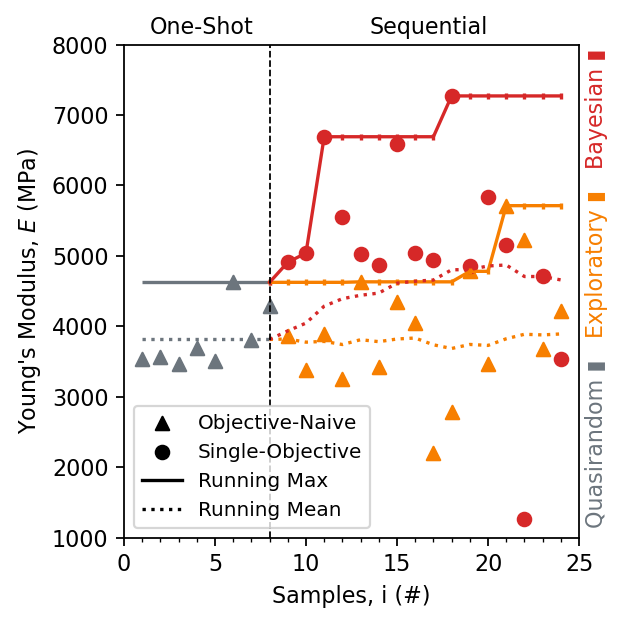

In [71]:
fig, ax1 = plt.subplots(figsize=(4, 4),dpi=160)

# Points
ax1.scatter(Prior_Indices_arr,Prior_QR_Naive_Y_mat[1],marker="^",color=Prior_Color)
ax1.scatter(Sequential_Indices_arr,Sequential_MIP_Naive_Y_mat[1],marker="^",color=MIP_Color)
ax1.scatter(Sequential_Indices_arr,Sequential_qLNEI_YM_Y_mat[1],color=qLNEI_YM_Color)

# Maximum Progression
ax1.hlines(y=np.max(Prior_QR_Naive_Y_mat[1]),xmin=1,xmax=8,color=Prior_Color)
ax1.plot(Sequential_Mean_Indices_arr,Sequential_MIP_YM_Progression_ȳ_arr,color=MIP_Color)
ax1.scatter(Sequential_Mean_Indices_arr,Sequential_MIP_YM_Progression_ȳ_arr,color=MIP_Color,marker="|",s=8)
ax1.plot(Sequential_Mean_Indices_arr,Sequential_qLNEI_YM_Progression_ȳ_arr,color=qLNEI_YM_Color)
ax1.scatter(Sequential_Mean_Indices_arr,Sequential_qLNEI_YM_Progression_ȳ_arr,color=qLNEI_YM_Color,marker="|",s=8)

# Mean Progression
ax1.hlines(y=InitialBenchmarkYoungsModulusMean,xmin=1,xmax=8,color=Prior_Color,linestyles="dotted")
ax1.plot(Sequential_Mean_Indices_arr,Sequential_MIP_YM_MeanProgression_ȳ_arr,color=MIP_Color,linestyle="dotted")
ax1.plot(Sequential_Mean_Indices_arr,Sequential_qLNEI_YM_MeanProgression_ȳ_arr,color=qLNEI_YM_Color,linestyle="dotted")

# Axes
ax1.set_ylabel(r"Young's Modulus, $E$ (MPa)")
ax1.set_xlabel("Samples, i (#)")

# Axes' Ticks
xlim=[0,25]
ylim=[1500,7500]
ax1.set_xlim(xlim[0],xlim[1])
ax1.set_ylim(ylim[0],ylim[1])
ax1.set_xticks(np.linspace(xlim[0],xlim[1],5+1))
ax1.set_yticks(np.linspace(1000,8000,7+1))
ax1.set_xticks(np.linspace(xlim[0],xlim[1],25+1),minor=True)

# One-Shot vs Sequential Split
ax1.vlines(x=8,ymin=1000,ymax=8000,color="black",linestyle="dashed",linewidth=0.8)
ax1.text(x=1.4,y=8150,s="One-Shot")
ax1.text(x=13.5,y=8150,s="Sequential")

# Marking Up
ax1.scatter(100000,100000,marker="^",color="black",label="Objective-Naive")
ax1.scatter(100000,100000,marker="o",color="black",label="Single-Objective")
ax1.plot([100000001,100000002],[100000001,100000002],color="black",label="Running Max")
ax1.plot([100000001,100000002],[100000001,100000002],linestyle="dotted",color="black",label="Running Mean")
ax1.text(x=25.3,y=1200,s="Quasirandom ▮",color=Prior_Color,rotation="vertical")
ax1.text(x=25.3,y=3900,s="Exploratory ▮",color=MIP_Color,rotation="vertical")
ax1.text(x=25.3,y=6300,s="Bayesian ▮",color=qLNEI_YM_Color,rotation="vertical")

plt.legend(fontsize=9,loc="lower left")

fig.tight_layout()
plt.savefig("SOBO-YM-Progression-STY")